In [2]:
import os
from pathlib import Path

import duckdb
import geopandas as gpd
import pandas as pd

In [10]:
data_path = Path(os.environ["DATA_PATH"])
generated_path = data_path / "generated"
scripts_path = Path("./scripts")

In [4]:
with (scripts_path / "01_registro.sql").open(encoding="utf8") as f:
    registro_query = f.read()
    duckdb.sql(registro_query)

df_orig = (
    pd.read_parquet("data/processed/choiceset.parquet")
    .dropna(subset=["partida_main"])
    .assign(
        fraccionamiento=lambda df: df["fraccionamiento"].str.casefold(),
        geometry=lambda df: gpd.points_from_xy(df["longitud"], df["latitud"]),
    )
    .drop(columns=["longitud", "latitud"])
    .pipe(gpd.GeoDataFrame, geometry="geometry", crs="EPSG:4326")
    .to_crs("EPSG:6372")
)

In [5]:
df_col = (
    gpd.read_file(data_path / "initial" / "lim_cols_cp")
    .dropna(subset=["COLONIAS"])
    .assign(
        COLONIAS=lambda df: (
            df["COLONIAS"]
            .str.casefold()
            .str.replace(r"fracc\.?", "", regex=True)
            .str.replace("fraccionamiento", "")
            .str.strip()
            .replace(
                {
                    "des. hab. privada campestre": "privadas campestre",
                    "camino del sol": "caminos del sol",
                    "balbuena condominios": "colonia balbuena",
                    "balbuena": "colonia balbuena",
                    "valle de puebla": pd.NA,  # Replace with NA to fill with specific section
                },
            )
            .where(lambda x: ~x.isna(), df["Col_Secc"].str.casefold())
            .str.replace("quinta etapa", "5ta secc.")
        ),
    )[["COLONIAS", "geometry"]]
    .dissolve(by="COLONIAS")
)

In [6]:
test = (
    gpd.read_file(data_path / "initial" / "lim_cols_cp")
    .drop(columns=["geometry"])[["Col_Secc"]]
    .dropna()
    .assign(Col_Secc=lambda df: df["Col_Secc"].str.casefold())
    .sort_values("Col_Secc")
)

In [7]:
test.loc[lambda df: df["Col_Secc"].str.contains("puebla")]

,Col_Secc
575,col. ampliacion ejido puebla ampliacion
486,ejido puebla
448,fracc. angeles de puebla
451,fracc. parajes de puebla
449,fracc. rincones de puebla
753,fracc. sol de puebla
438,fracc. sol de puebla
450,mision de puebla
682,parajes de puebla segunda seccion etapa 1
683,parajes de puebla segunda seccion etapa 2


In [8]:
df_col.loc[df_col.index.str.contains("rioja")].sort_index()

,geometry
COLONIAS,
la rioja cerrada andalucia,"POLYGON ((653470.079 3614228.828, 653241.578 3..."
la rioja cerrada catalusa,"POLYGON ((653115.03 3614225.115, 652979.122 36..."
la rioja cerrada galicia,"POLYGON ((653179.595 3614489.591, 653173.427 3..."
la rioja cerrada navarra,"POLYGON ((653467.391 3614484.502, 653468.545 3..."
la rioja seccion castilla,"POLYGON ((653470.079 3614228.828, 653468.752 3..."


In [9]:
fracc = df_orig["fraccionamiento"].drop_duplicates()
fracc[~fracc.isin(df_col.index)]

0                     privadas condesa
48552     la rioja seccion castillauna
103667              residencial natura
200701                    foresta life
263946            fontalba residencial
427574       colonia granjas agricolas
461416            corceles residencial
791826                quinta granada 3
863471                    gran foresta
Name: fraccionamiento, dtype: object

In [150]:
fracc

0                     privadas condesa
31                  privadas campestre
64                   angeles de puebla
216                    caminos del sol
257                  parajes de puebla
1616                rincones de puebla
2798                  colonia balbuena
23901        valle de puebla 5ta secc.
46925                       san andres
48552     la rioja seccion castillauna
93071                   quinta granada
93840               porticos del valle
103264                       villanova
103667              residencial natura
156749              valle del progreso
194059            huertas del colorado
200701                    foresta life
263946            fontalba residencial
318875           bonaterra residencial
427574       colonia granjas agricolas
461416            corceles residencial
577894               ibiza residencial
791826                quinta granada 3
797278                   valle oriente
863471                    gran foresta
Name: fraccionamiento, dt

In [11]:
df_mesh = gpd.read_file(generated_path / "mesh_accessibility.gpkg")

In [16]:
df_access = (
    gpd.GeoDataFrame(
        df_col[["geometry"]].to_crs("EPSG:6372")
        .sjoin(df_mesh[["geometry", "accessibility_score"]], how="left")
        .groupby("COLONIAS")
        .agg({"accessibility_score": "mean", "geometry": "first"}),
        crs=df_mesh.crs,
    )
    .reset_index()
    .rename(columns={"accessibility_score": "accessibility"})
)

<Axes: >

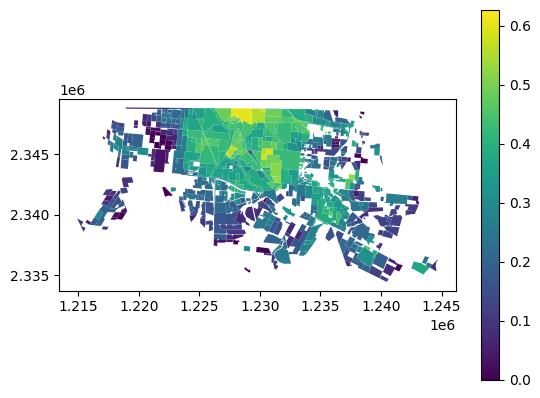

In [18]:
df_access.plot(column="accessibility", cmap="viridis", legend=True)